# Otus benchmark results

This notebook loads the Google Benchmark JSON files with pandas, separates the benchmark dimensions with anchored regular expressions, and compares reported throughput across implementations. Change `RESULT_SET` to analyze another result directory.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from pernix_benchmark_tools.results import (
    CP2K_BENCHMARK_RE,
    PERNIX_BENCHMARK_RE,
    load_benchmark_contexts,
    load_benchmark_results,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

RESULT_SET = "otus-2018261"


def find_repository_root() -> Path:
    for start in (Path.cwd().resolve(), Path.cwd().resolve().parent):
        for candidate in (start, *start.parents):
            if (candidate / "benchmark-tools" / "pyproject.toml").is_file():
                return candidate
    raise FileNotFoundError("Could not find the pernix-benchmark checkout")


REPOSITORY_ROOT = find_repository_root()
RESULT_DIR = REPOSITORY_ROOT / "benchmark-results" / RESULT_SET
RESULT_DIR

PosixPath('/home/woobb/Projects/pernix-benchmark/benchmark-results/otus-2018261')

## Load and normalize

Pernix and CP2K use different benchmark-name shapes. The reusable loader applies the two expressions below and fails if any name is not fully matched, preventing partially parsed rows from silently entering a plot.

In [2]:
display(Markdown(f"**Pernix regex:** `{PERNIX_BENCHMARK_RE.pattern}`"))
display(Markdown(f"**CP2K regex:** `{CP2K_BENCHMARK_RE.pattern}`"))

results = load_benchmark_results(RESULT_DIR)
contexts = load_benchmark_contexts(RESULT_DIR)

dimension_columns = [
    "implementation",
    "direction",
    "value_type",
    "memory_mode",
    "bit_width",
    "blocks",
]
assert not results[dimension_columns].isna().any().any()
assert (results["bytes_per_second"] > 0).all()

pd.DataFrame(
    {
        "value": [
            len(results),
            results["source_file"].nunique(),
            results["implementation"].nunique(),
            int(results["bit_width"].min()),
            int(results["bit_width"].max()),
            int(results["blocks"].min()),
            int(results["blocks"].max()),
        ]
    },
    index=[
        "rows",
        "result files",
        "implementations",
        "minimum bit width",
        "maximum bit width",
        "minimum blocks",
        "maximum blocks",
    ],
)

**Pernix regex:** `^BM_(?P<direction>compress|decompress)_(?P<implementation>[A-Za-z0-9]+?)(?P<value_type>f32|f64)_(?P<core_throughput>true|false)_(?P<bit_width>\d+)/(?P<blocks>\d+)$`

**CP2K regex:** `^BM_cp2k_(?P<direction>compression|decompression)/width(?P<bit_width>\d+)/(?P<blocks>\d+)/manual_time$`

,value
rows,18078
result files,5
implementations,5
minimum bit width,1
maximum bit width,24
minimum blocks,1
maximum blocks,4194304


## Run context and data quality

The fallback executable was measured with a different reported CPU frequency and a much higher load average. Its measurements remain in the analysis, but comparisons involving fallback should be interpreted with that run-to-run difference in mind.

In [3]:
machine_state_path = RESULT_DIR / "machinestate.json"
machine_state = (
    json.loads(machine_state_path.read_text(encoding="utf-8"))
    if machine_state_path.is_file()
    else {}
)
cpu_name = machine_state.get("CpuInfo", {}).get("Name", "unknown CPU")
display(Markdown(f"**Host CPU:** {cpu_name}"))

context_summary = contexts[[
    "implementation",
    "host_name",
    "date",
    "mhz_per_cpu",
    "load_avg",
    "library_version",
]].copy()
context_summary[["load_1m", "load_5m", "load_15m"]] = pd.DataFrame(
    context_summary.pop("load_avg").tolist(), index=context_summary.index
)
context_summary

**Host CPU:** AMD EPYC 9655 96-Core Processor

,implementation,host_name,date,mhz_per_cpu,library_version,load_1m,load_5m,load_15m
0,avx2,cn0761,2026-07-17T00:36:09+02:00,2600,v1.9.4,1.39,1.38,2.28
1,avx512vbmi,cn0761,2026-07-17T03:10:47+02:00,2600,v1.9.4,1.16,1.32,1.33
2,bmi2,cn0761,2026-07-17T01:53:12+02:00,2600,v1.9.4,1.20,1.17,1.18
3,cp2k,cn0761,2026-07-17T04:28:58+02:00,2600,v1.9.4,1.19,1.20,1.24
4,fallback,cn0761,2026-07-16T23:17:29+02:00,2070,v1.9.4,8.52,99.63,156.25


## Benchmark coverage

Each cell is the number of measurements available for a normalized benchmark family. Corrected CP2K runs cover f32 and f64 in cache-hot core and full-throughput modes for widths 1–24; legacy files are f64/full-only and cover widths 8–16.

In [4]:
coverage = (
    results.groupby(
        ["implementation", "direction", "value_type", "memory_mode"],
        observed=True,
    )
    .size()
    .unstack(["direction", "value_type", "memory_mode"], fill_value=0)
)
coverage

direction      compression                decompression               
value_type             f32       f64                f32       f64     
memory_mode           core full core full          core full core full
implementation                                                        
avx2                   552  552  552  552           552  552  552  552
avx512vbmi             552  552  552  552           552  552  552  552
bmi2                   552  552  552  552           552  552  552  552
cp2k                     0    0    0  207             0    0    0  207
fallback               552  552  552  552           552  552  552  552

## Peak reported throughput

For each bit width, this view selects the highest reported bytes/second across all tested block counts. `core` reuses small cache-hot buffers and excludes one side of memory traffic from byte accounting; `full` streams distinct blocks and includes input plus output traffic. The kernels still execute loads and stores. The next cell reports whether loaded CP2K rows use corrected or legacy accounting.

> **Legacy CP2K caveat:** these rows use the old byte-accounting formula. Their absolute GiB/s values and speedups are provisional; rerun `bench_cp2k` to produce corrected `pernix_v1` results.

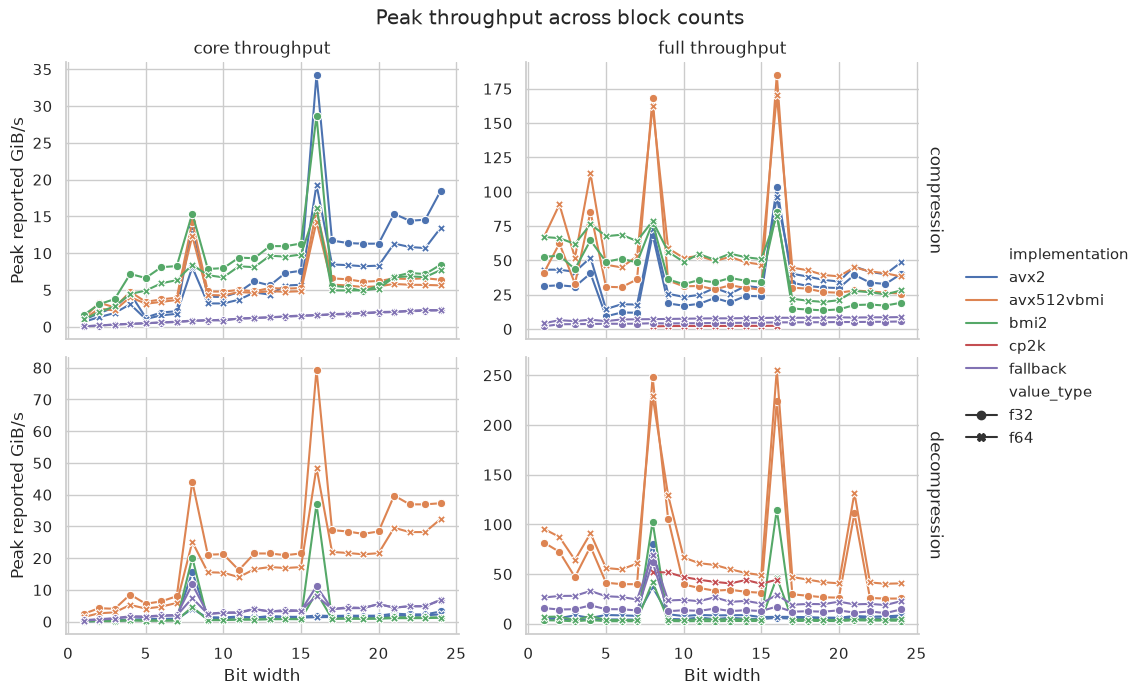

In [5]:
cp2k_schemas = set(results.loc[results["implementation"] == "cp2k", "benchmark_schema"])
if "cp2k_legacy" in cp2k_schemas:
    display(Markdown(
        "> **Legacy CP2K caveat:** these rows use the old byte-accounting formula. Their absolute GiB/s values and speedups are provisional; rerun `bench_cp2k` to produce corrected `pernix_v1` results."
    ))
elif cp2k_schemas:
    display(Markdown(
        "> **CP2K accounting:** corrected `pernix_v1` rows use the same logical-byte formula as the matching Pernix full-throughput benchmarks."
    ))

peak = (
    results.groupby(
        [
            "implementation",
            "direction",
            "value_type",
            "memory_mode",
            "bit_width",
        ],
        as_index=False,
        observed=True,
    )["gib_per_second"]
    .max()
)

grid = sns.relplot(
    data=peak,
    x="bit_width",
    y="gib_per_second",
    hue="implementation",
    style="value_type",
    row="direction",
    col="memory_mode",
    kind="line",
    markers=True,
    dashes=False,
    facet_kws={"sharey": False, "margin_titles": True},
    height=3.4,
    aspect=1.45,
)
grid.set_axis_labels("Bit width", "Peak reported GiB/s")
grid.set_titles(row_template="{row_name}", col_template="{col_name} throughput")
grid.figure.suptitle("Peak throughput across block counts", y=1.02)
plt.show()

## Scaling with block count

Widths 8, 16, and 24 provide compact low/mid/high-width views. Width 24 has no CP2K measurements. The x-axis uses the powers-of-two block counts from Google Benchmark.

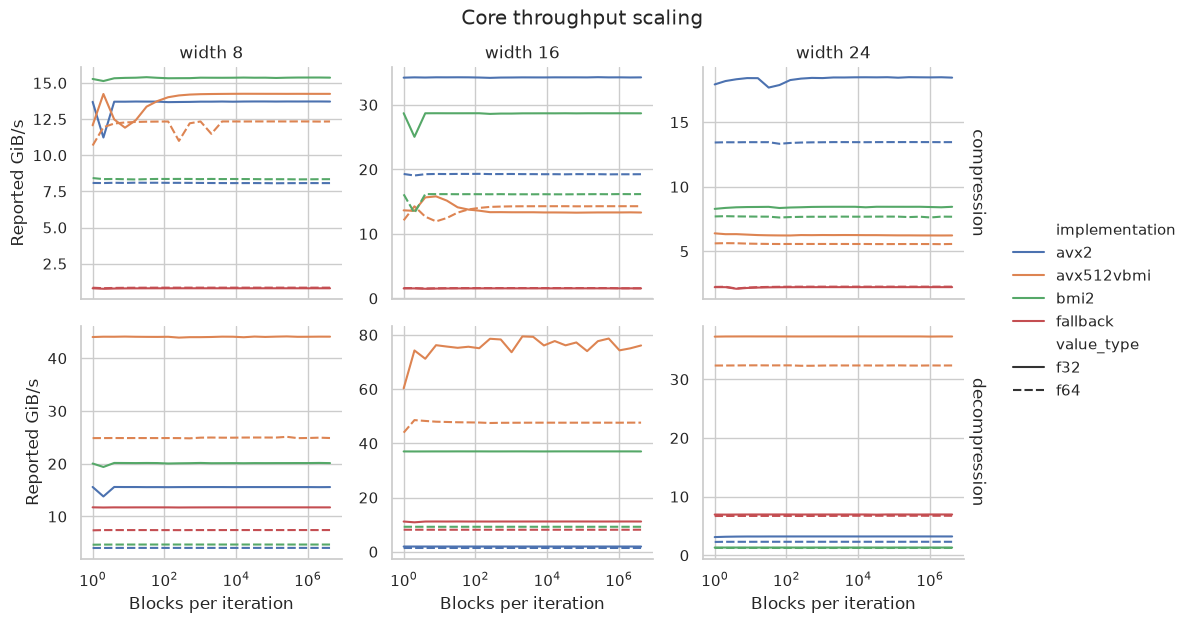

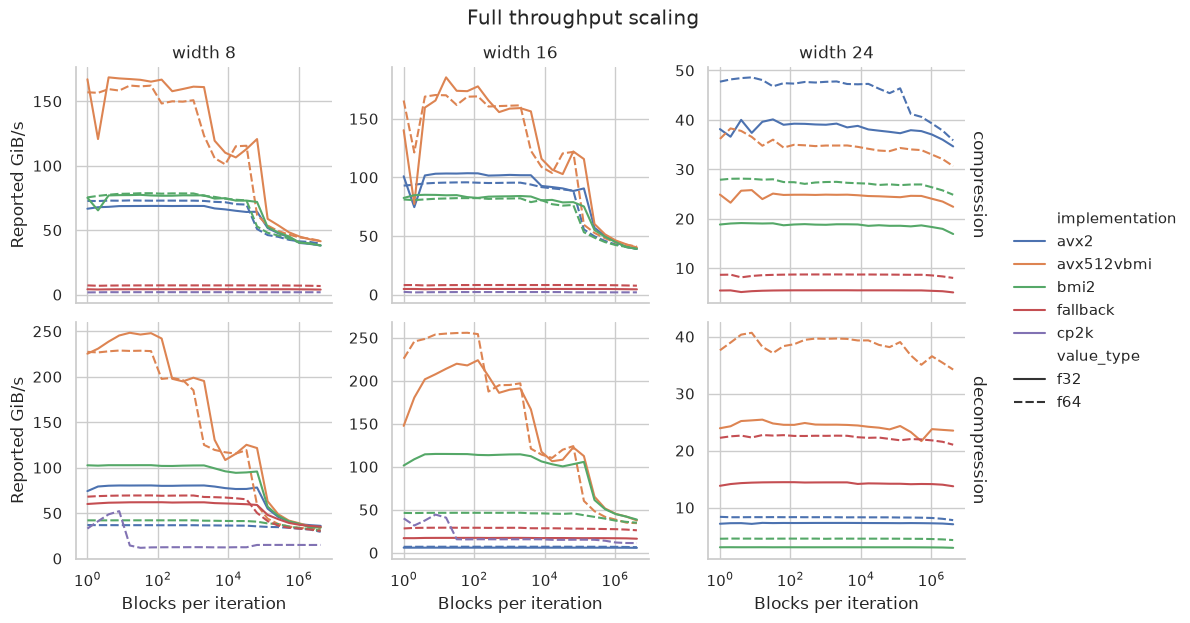

In [6]:
representative_widths = [8, 16, 24]
scaling = results[results["bit_width"].isin(representative_widths)]

for memory_mode in ("core", "full"):
    subset = scaling[scaling["memory_mode"] == memory_mode]
    grid = sns.relplot(
        data=subset,
        x="blocks",
        y="gib_per_second",
        hue="implementation",
        style="value_type",
        row="direction",
        col="bit_width",
        col_order=representative_widths,
        kind="line",
        facet_kws={"sharey": False, "margin_titles": True},
        height=3.0,
        aspect=1.15,
    )
    grid.set(xscale="log")
    grid.set_axis_labels("Blocks per iteration", "Reported GiB/s")
    grid.set_titles(row_template="{row_name}", col_template="width {col_name}")
    grid.figure.suptitle(f"{memory_mode.title()} throughput scaling", y=1.03)
    display(grid.figure)
    plt.close(grid.figure)

## Matched speedup over fallback

Rows are matched on direction, value type, memory mode, bit width, and block count before computing a ratio. The heatmaps then retain the largest ratio observed across block counts for each width. Ratios from legacy CP2K rows inherit the accounting warning shown above.

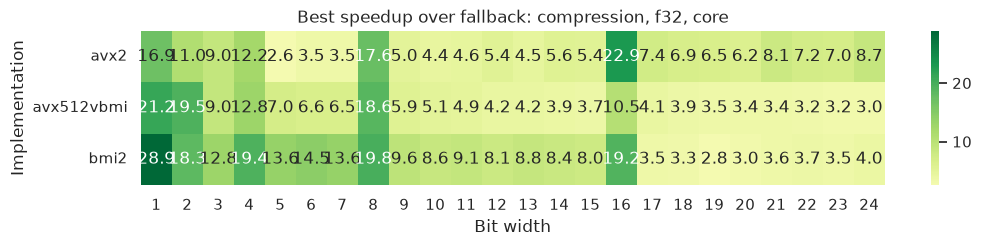

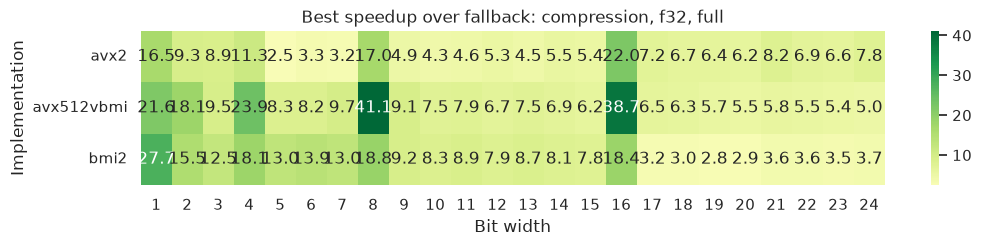

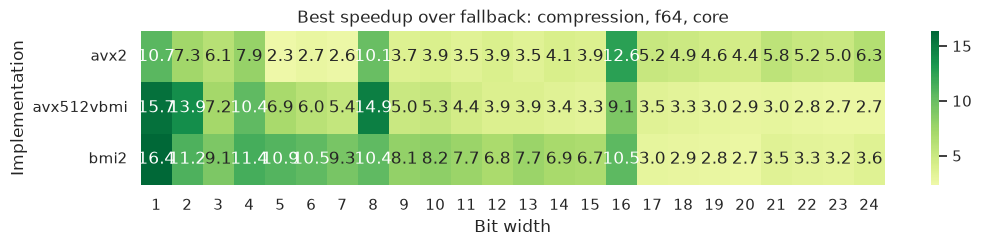

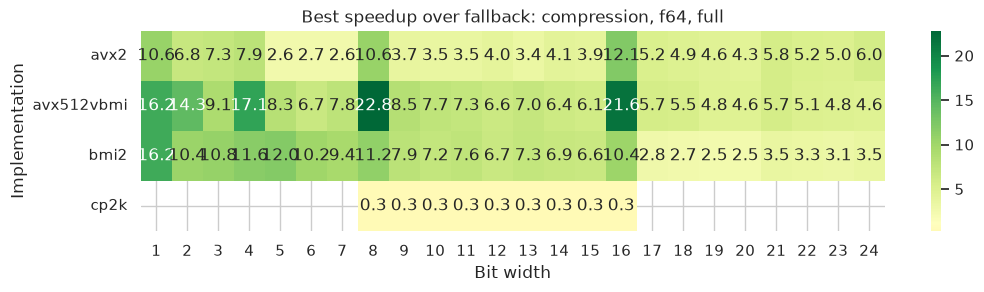

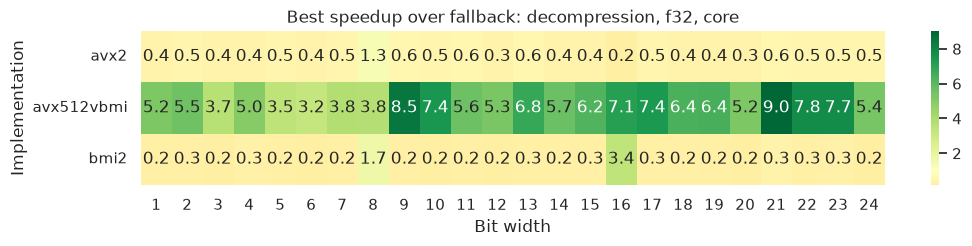

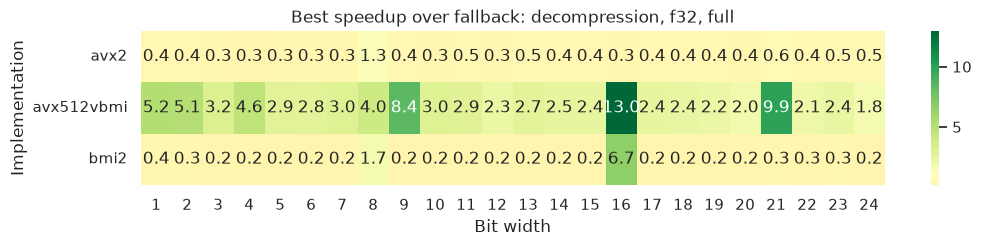

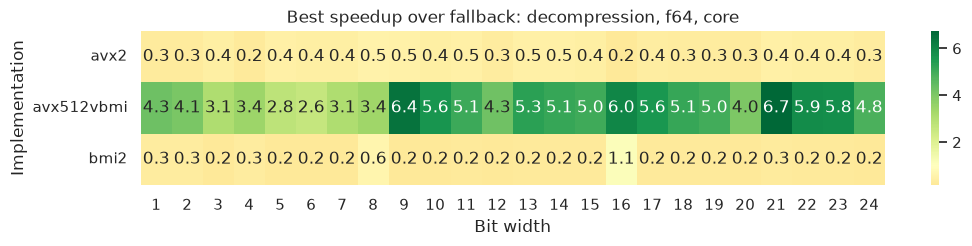

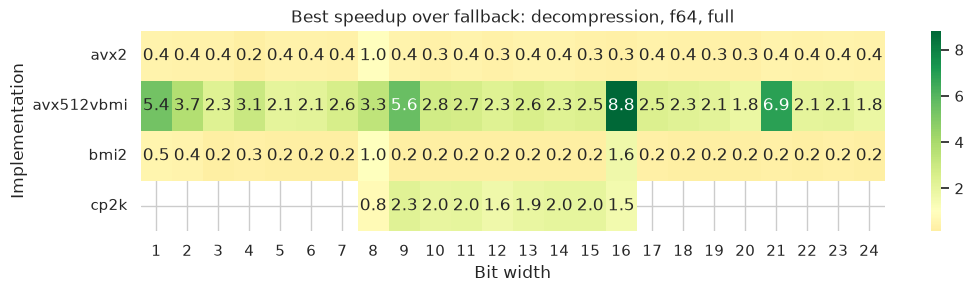

In [7]:
match_keys = ["direction", "value_type", "memory_mode", "bit_width", "blocks"]
fallback = (
    results[results["implementation"] == "fallback"][
        match_keys + ["bytes_per_second"]
    ]
    .rename(columns={"bytes_per_second": "fallback_bytes_per_second"})
)
speedups = results.merge(fallback, on=match_keys, how="inner", validate="many_to_one")
speedups["speedup_over_fallback"] = (
    speedups["bytes_per_second"] / speedups["fallback_bytes_per_second"]
)
best_speedups = (
    speedups[speedups["implementation"] != "fallback"]
    .groupby(
        [
            "implementation",
            "direction",
            "value_type",
            "memory_mode",
            "bit_width",
        ],
        as_index=False,
        observed=True,
    )["speedup_over_fallback"]
    .max()
)

for (direction, value_type, memory_mode), subset in best_speedups.groupby(
    ["direction", "value_type", "memory_mode"], observed=True
):
    matrix = subset.pivot(
        index="implementation", columns="bit_width", values="speedup_over_fallback"
    )
    fig, ax = plt.subplots(figsize=(12, max(2.0, 0.65 * len(matrix))))
    sns.heatmap(matrix, cmap="RdYlGn", center=1.0, annot=True, fmt=".1f", ax=ax)
    ax.set_title(f"Best speedup over fallback: {direction}, {value_type}, {memory_mode}")
    ax.set_xlabel("Bit width")
    ax.set_ylabel("Implementation")
    plt.show()

## Winners and optimal block counts

The first table records each implementation's optimal tested block count. The second selects the highest-throughput implementation for every direction/type/mode/width combination.

In [8]:
configuration = [
    "implementation",
    "direction",
    "value_type",
    "memory_mode",
    "bit_width",
]
optimal_rows = results.loc[
    results.groupby(configuration, observed=True)["bytes_per_second"].idxmax()
].copy()
optimal_blocks = optimal_rows[configuration + ["blocks", "gib_per_second"]].sort_values(
    configuration
)
display(Markdown("### Optimal tested block count per implementation (first 30 rows)"))
display(optimal_blocks.head(30))

comparison_keys = ["direction", "value_type", "memory_mode", "bit_width"]
winners = optimal_rows.loc[
    optimal_rows.groupby(comparison_keys, observed=True)["bytes_per_second"].idxmax()
][comparison_keys + ["implementation", "blocks", "gib_per_second"]].sort_values(
    comparison_keys
)
display(Markdown("### Winning implementation by matched configuration"))
display(winners)

display(Markdown("### Number of wins"))
winners["implementation"].value_counts().rename("wins").to_frame()

### Optimal tested block count per implementation (first 30 rows)

,implementation,direction,value_type,memory_mode,bit_width,blocks,gib_per_second
52,avx2,compression,f32,core,1,8192,0.933739
136,avx2,compression,f32,core,2,2048,1.847355
236,avx2,compression,f32,core,3,8192,2.656206
276,avx2,compression,f32,core,4,1,4.525292
428,avx2,compression,f32,core,5,32768,1.259103
504,avx2,compression,f32,core,6,2048,1.942033
620,avx2,compression,f32,core,7,131072,2.121907
704,avx2,compression,f32,core,8,32768,13.716866
820,avx2,compression,f32,core,9,2097152,4.093512
916,avx2,compression,f32,core,10,4194304,4.054062


### Winning implementation by matched configuration

,direction,value_type,memory_mode,bit_width,implementation,blocks,gib_per_second
2,compression,f32,core,1,bmi2,1,1.596846
105,compression,f32,core,2,avx512vbmi,8,3.274416
274,compression,f32,core,3,bmi2,4194304,3.763912
330,compression,f32,core,4,bmi2,8192,7.178397
370,compression,f32,core,5,bmi2,1,6.634648
...,...,...,...,...,...,...,...
17627,decompression,f64,full,20,avx512vbmi,4,40.710838
17727,decompression,f64,full,21,avx512vbmi,16,131.611331
17811,decompression,f64,full,22,avx512vbmi,4,41.578074
17903,decompression,f64,full,23,avx512vbmi,4,40.254132


### Number of wins

,wins
implementation,
avx512vbmi,115
bmi2,49
avx2,28
